In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

# 1) Data & EDA (Isabel)

- Visa datasetstorlek, datatyper och target-fördelning.
- Kontrollera saknade värden och beskriv hur ni hanterar dem.
- Minst 2 figurer/tabeller + kort tolkning.

In [3]:
df = pd.read_csv("historical_data.csv")
df.head()

,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [4]:
print("Datasets storlek:", df.shape)
print("---------------------------")

Datasets storlek: (12000, 18)
---------------------------


In [5]:
print("Datatyper")
print("---------------------------")
df.info()

Datatyper
---------------------------
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  cont

### Summering av dataset

- Datasetet innehåller 12,000 observationer och 18 variabler
- Text variabler är av typ *string* och numeriska variabler är av typerna *int64* och *float64*
- Det finns fyra kategoriska värden: *event_type*, *category*, *region*, *device*
- Target är *is_suspicious*: 0 = ej misstänkt, 1 = misstänkt

## Missing values

In [6]:
print("-------------------------------")
print("Saknade värden per kolumn (antal):")
print("-------------------------------")
print(df.isna().sum())
print("-------------------------------")
print("Saknade värden per kolumn (%):")
print("-------------------------------")
df.isnull().sum() / len(df) * 100

-------------------------------
Saknade värden per kolumn (antal):
-------------------------------
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64
-------------------------------
Saknade värden per kolumn (%):
-------------------------------


id                            0.000000
day                           0.000000
event_type                    0.000000
category                      0.000000
region                        2.833333
device                        0.000000
account_age_days              0.000000
num_prev_listings             0.000000
prev_reports_30d              0.000000
verification_level            0.000000
price                         6.816667
num_images                    0.000000
message_length                0.000000
contains_off_platform         0.000000
urgency_words                 0.000000
payment_attempt               0.000000
time_to_first_response_min    4.916667
is_suspicious                 0.000000
dtype: float64

### Hantering av saknade värden

Andelen saknade värden är relativt låg:
- *region*: 340 (2.83 %)
- *price*: 818 (6.81 %)
- *time_to_first_response_min*: 590 (4.91%)

Eftersom klassen är obalanserad är det mindre lämpligt att droppa rader, då procent av saknade värden inte är tillräckligt låg, i ett redan obalancerat problem kan minoiritetsklassen påverkas oproportioneligt. I detta fall är det istället bättre att imputera värdena.

**Hantering - Alternativ 1: Fyll i saknade värden**
- *region*: Skapa en ny kategori - `region = region.fillna("Unknown")`
- *price*: Median-imputering - `price = price.fillna(price.median())`
- *time_to_first_response_min*: Median-imputering - `time_to_first_response_min = time_to_first_response_min.fillna(time_to_first_response_min.median())`

**Hantering - Alternativ 2: Imputering med SimpleImputor**

**Numeriska varibler:** *price* och *time_to_first_response_min*

`SimpleImputer(strategy="median", add_indicator=True)`

*add_indicator=True* --> Skapar automatiskt en binär kolumn som visar om värdet var saknat, det hjälper modellen att se mönster om det finns ett samband mellan saknade värden och misstänkt/ej misttänkt aktivitet. 

**Kategorisk variabler:** *region*

`SimpleImputer(strategy="constant", fill_value="Unknown")`

Saknade värden i kategoriska variabler är ofta informativt. "Unknown" låter modellen behandla det som en egen kategori och hjälper modellen att se mönster om det finns ett samband mellan saknade värden och misstänkt/ej misttänkt aktivitet. Alternativ är `SimpleImputer(strategy="most_frequent")`. 

## Definera X och y

In [7]:
X_full = df.drop(["is_suspicious"], axis=1)
y_full = df["is_suspicious"]

print("X:", X_full.shape, "y:", y_full.shape)

X: (12000, 17) y: (12000,)


## Klassfördelning av target (misstänkt aktivitet)

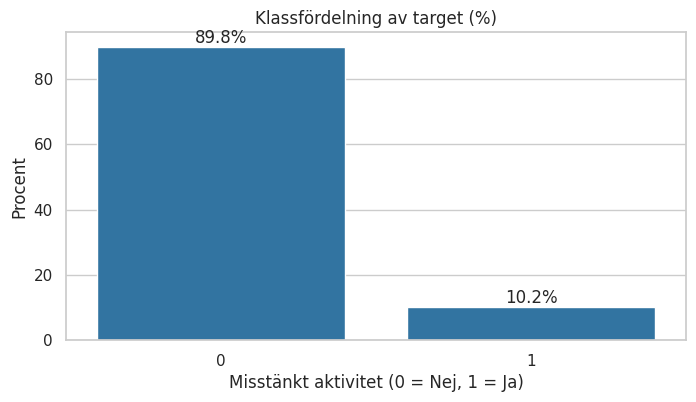

In [8]:
class_dist = y_full.value_counts(normalize=True) * 100

ax = sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)

plt.ylabel("Procent")
plt.xlabel("Misstänkt aktivitet (0 = Nej, 1 = Ja)")
plt.title("Klassfördelning av target (%)")

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

### Summering av klassfördelning
Klassfördelningen visar en tydlig obalans i datan: endast 10 % av de historiska observationerna är klassade som misstänkt aktivitet. Detta är dock förväntat, eftersom andelen misstänkt aktivitet normalt sett är låg.

## Korrelationer med target (misstänkt aktivitet)

Korrelationer visar hur starkt numeriska features separerar misstänkt aktivitet från icke-misstänkt. Kategoriska variabler utesluts eftersom korrelation mäter det linjära sambandet mellan två numeriska variabler.

In [9]:
corr_with_target = X_full.copy()
corr_with_target["is_suspicious"] = y_full

corr_with_target = (
    corr_with_target
    .drop(["event_type", "category", "region", "device"], axis=1)
    .corr()["is_suspicious"]
    .sort_values(ascending=False)
)

print(corr_with_target)

is_suspicious                 1.000000
contains_off_platform         0.141828
prev_reports_30d              0.130920
urgency_words                 0.087295
payment_attempt               0.066666
price                         0.011883
num_images                    0.009446
id                            0.005236
day                          -0.007565
message_length               -0.011989
time_to_first_response_min   -0.013942
num_prev_listings            -0.015895
verification_level           -0.100409
account_age_days             -0.103146
Name: is_suspicious, dtype: float64


### Summering korrelerande features

De två features som visar högst positiv korrelation med misstänkt aktivitet är *contains_off_platform* (0,14) och *prev_reports_30d* (0,13). Även om dessa samband är relativt svaga kan de ändå vara värdefulla i obalanserade klassificeringsproblem, eftersom effekten sannolikt är icke-linjär. Det finns troligen en tröskeleffekt, och dessa features kan ha större betydelse i kombination med andra variabler.

## Andel misstänka aktiviteter per kategori

Andelen misstänkt aktivitet analyseras för respektive kategorisk variabel för att undersöka om någon kategori sticker ut med en högre förekomst av misstänkt aktivitet.

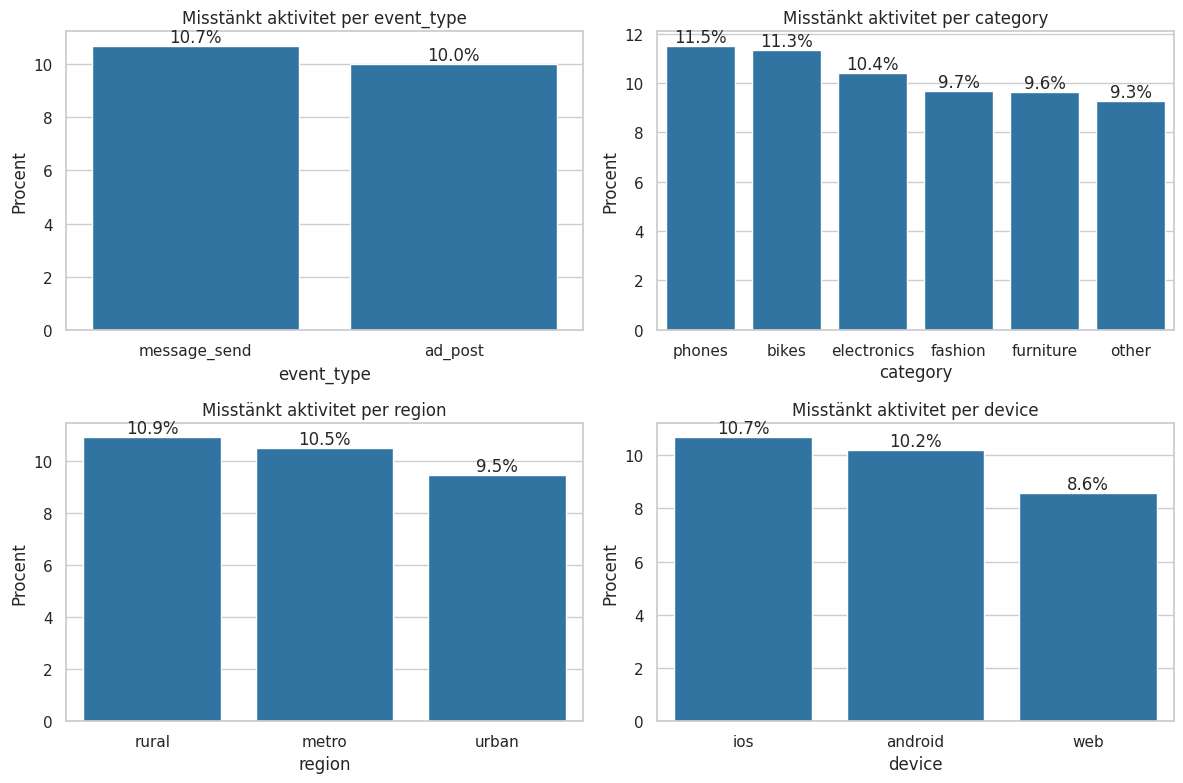

In [10]:
categorical_cols = [
    "event_type",
    "category",
    "region",
    "device"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  
axes = axes.flatten() 

temp_df = pd.concat([X_full, y_full.rename("is_suspicious")], axis=1)

for i, col in enumerate(categorical_cols):
    susp_count = (
        temp_df
        .groupby(col)["is_suspicious"]
        .mean()
        .sort_values(ascending=False) * 100
    )
    
    ax = sns.barplot(
        x=susp_count.index,
        y=susp_count.values,
        ax=axes[i]
    )
    
    ax.set_ylabel("Procent")
    ax.set_title(f"Misstänkt aktivitet per {col}")
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Summering av misstänkt aktivitet per kategori
Analysen av historisk data visar inga tydliga skillnader mellan kategorier när det gäller andelen misstänkt aktivitet. Fördelningen av misstänkta händelser inom de olika kategorierna speglar i stort den övergripande klassfördelningen och ligger konsekvent runt 10 %.

# 2) Pipeline & preprocessing (Irene)

- Skapa en train/test-split från historical_data.csv.
- Bygg en pipeline där preprocessing sker på ett sätt som undviker att testdata påverkar träningen (undvik leakage).
- För klassificering: använd gärna stratified split så klasserna fördelas rimligt.

Kolumnnamn | Förklaring |
|---|---|
| `id` | Unikt identifieringsnummer för varje post |
| `day` | Dagen då händelsen inträffade |
| `event_type` | Typ av händelse (t.ex. visning, meddelande, anmälan) |
| `category` | Produktkategori för annonsen |
| `region` | Geografiskt område där annonsen publicerades |
| `device` | Enhetstyp som användes (t.ex. mobil, dator) |
| `account_age_days` | Antal dagar sedan kontot skapades |
| `num_prev_listings` | Antal tidigare annonser från samma användare |
| `prev_reports_30d` | Antal gånger användaren anmälts de senaste 30 dagarna |
| `verification_level` | Verifieringsnivå för kontot |
| `price` | Annonsens pris |
| `num_images` | Antal bilder i annonsen |
| `message_length` | Längden på meddelandet i annonsen |
| `contains_off_platform` | Om användaren försökt flytta konversationen utanför plattformen |
| `urgency_words` | Om annonsen innehåller ord som skapar artificiell brådska |
| `payment_attempt` | Om ett betalningsförsök har skett |
| `time_to_first_response_min` | Tid i minuter till första svar |
| `is_suspicious` | Målvariabel — om annonsen är misstänkt (1) eller inte (0) |

In [ ]:
# Train/test split
# X_full and y_full were defined higher up

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("-------------------------------")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("-------------------------------")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")
print("-------------------------------")

# Pipeline
    # Feature engeneering
    # Imputation
    # Encoding
    # Scaling
    # Model

Train: (9600, 17) (9600,)
Test: (2400, 17) (2400,)
-------------------------------
Classification train: 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64
-------------------------------
lassification test: 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64
-------------------------------


# 3) Modelljämförelse (Nora)

- Skapa en baseline.
- Träna minst två ytterligare modeller (minst 3 totalt inkl baseline).
- Utvärdera med rimlig metod (t.ex. cross-validation på train eller tydligt valideringsupplägg)
- Välj metric och motivera valet utifrån ert kravkort.
- (Exempel på modeller: LogisticRegression, DecisionTree, RandomForest, GradientBoosting…)

# 4) Optimering (Ummulbanin)

- Välj en “final” modell baserat på jämförelsen.
- Gör tuning på den valda modellen (litet grid, minst 1–2 parametrar).
- Förklara kort vad ni optimerade och varför (koppla till kravkortet).

# 5) Threshold/prioritering (Abdullahi)

Ni måste bestämma hur modellen ska användas i praktiken. Välj en strategi:

    A) Threshold-beslut
    - flagga misstänkt om proba ≥ t
    - motivera t utifrån kravkortet och visa konsekvenser (FP/FN eller precision/recall)
    
    B) Top-X prioritering
    - flagga de X% högst risk (t.ex. top 5% eller top 50 per dag)
    - motivera X utifrån kravkortet och visa konsekvenser
    - Ni ska tydligt visa hur ert val påverkar FP/FN och varför det passar er stakeholder.

# 6) Deploy-test: ny data (tisdag kursvecka 6)

- När ni får new_data.csv ska ni:
- använda er låsta pipeline
- skapa prediktioner och en prioriteringslista